# Analyzing Software Engineering as a Lifecycle Process
- Modeling and concept mapping
- Rolling IQR anomaly detection
- Utility experiment


## 1. Load DuckDB and build weekly counts


Dataset: TradingAgents
DuckDB: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\TradingAgents.duckdb
OCEL2: C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\data\raw\TradingAgents.sqlite
Closed event type id: 178


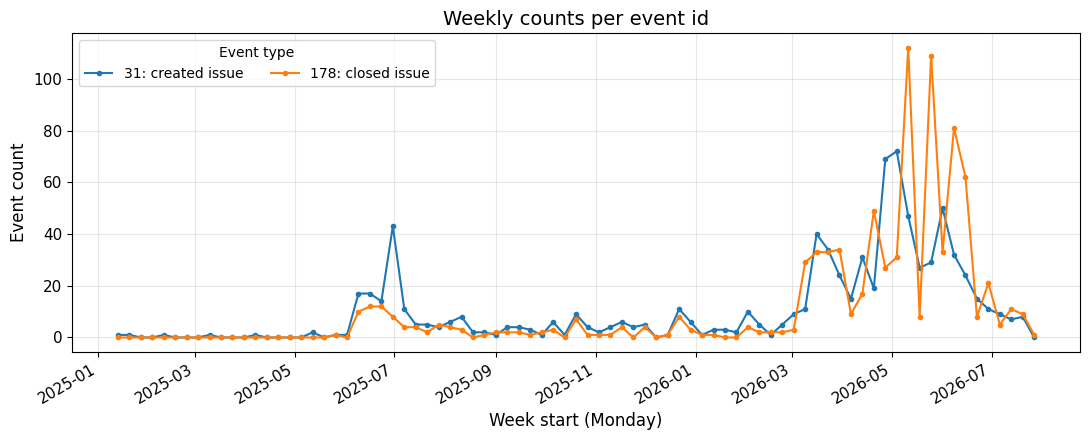

Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\weekly_open_closed_summary.csv


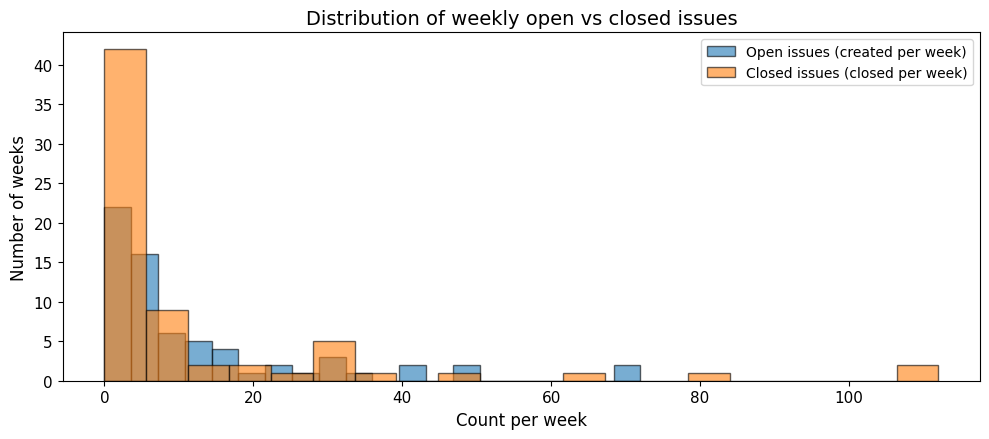

,Open issues (weekly created),Closed issues (weekly closed)
count,67.00,67.00
mean,12.36,12.61
std,15.93,23.18
min,0.00,0.00
25%,2.00,1.00
50%,6.00,3.00
75%,15.00,10.50
max,72.00,112.00


In [1]:
import sys
from pathlib import Path

root = Path.cwd().resolve()
if not (root / "functions").exists():
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from functions.configs import load_dataset_config
from functions.data_loading import (
    build_weekly_issue_counts,
    load_events_per_obj,
    load_objects_attributes,
)
from functions.plotting_anomaly import (
    plot_weekly_event_counts,
    plot_weekly_open_vs_closed_histogram,
    weekly_open_closed_summary_table,
)

# The only dataset-specific line in this notebook.
cfg = load_dataset_config("TradingAgents")

cfg.tables_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_dir.mkdir(parents=True, exist_ok=True)
cfg.figures_no_titles_dir.mkdir(parents=True, exist_ok=True)

print("Dataset:", cfg.dataset_name)
print("DuckDB:", cfg.duckdb_path)
print("OCEL2:", cfg.sqlite_path)
print("Closed event type id:", cfg.closed_event_type_id)

eventsPerobj_df = load_events_per_obj(cfg)
objects_attributes = load_objects_attributes(cfg)
weekly = build_weekly_issue_counts(eventsPerobj_df, cfg)
plot_weekly_event_counts(weekly, cfg)
summary_table = weekly_open_closed_summary_table(weekly, cfg)
plot_weekly_open_vs_closed_histogram(weekly, cfg)
summary_table


## 2. Rolling IQR for detecting the anomalies 


In [2]:
from functions.anomaly import rolling_iqr_detect
from functions.config import IQR_CONFIG

rolling_iqr_anomalies = rolling_iqr_detect(
    weekly[cfg.closed_event_type_id],
    **IQR_CONFIG,
)
rolling_iqr_anomalies.to_csv(cfg.tables_dir / "rolling_iqr_anomalies.csv", index=False)
print(
    f"Detected {int(rolling_iqr_anomalies['is_anomaly'].sum())} "
    f"rolling-IQR anomalies for event_type_id={cfg.closed_event_type_id}."
)
rolling_iqr_anomalies.head()


Detected 15 rolling-IQR anomalies for event_type_id=178.


,week_start,value,rolling_q1,rolling_q3,iqr,lower_bound,upper_bound,is_anomaly,anomaly_direction,anomaly_score
0,2025-01-13,0,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
1,2025-01-20,0,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
2,2025-02-10,0,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
3,2025-03-10,0,NaN,NaN,NaN,NaN,NaN,False,normal,0.0
4,2025-04-07,0,NaN,NaN,NaN,NaN,NaN,False,normal,0.0


## 3. Export anomaly object / event IDs


In [4]:
from functions.anomaly_ids import export_anomaly_ids

anomaly_object_ids, anomaly_event_ids = export_anomaly_ids(
    rolling_iqr_anomalies, eventsPerobj_df, cfg
)
anomaly_object_ids.head()



,week_start,object_id
0,2026-06-08,23472
1,2026-06-08,23808
2,2026-05-25,28485
3,2026-05-25,28638
4,2026-06-08,29106


## 4. Anomaly plots


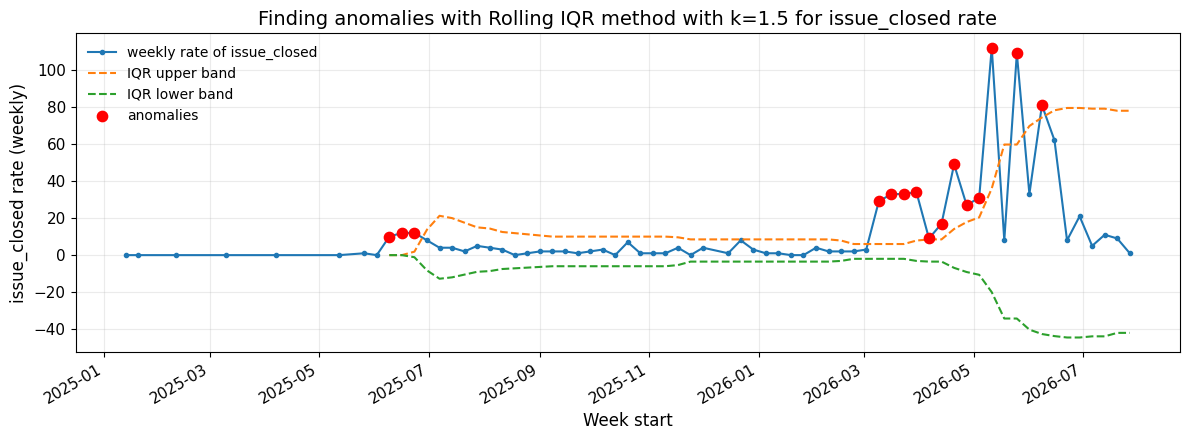

C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\functions\plotting_anomaly.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


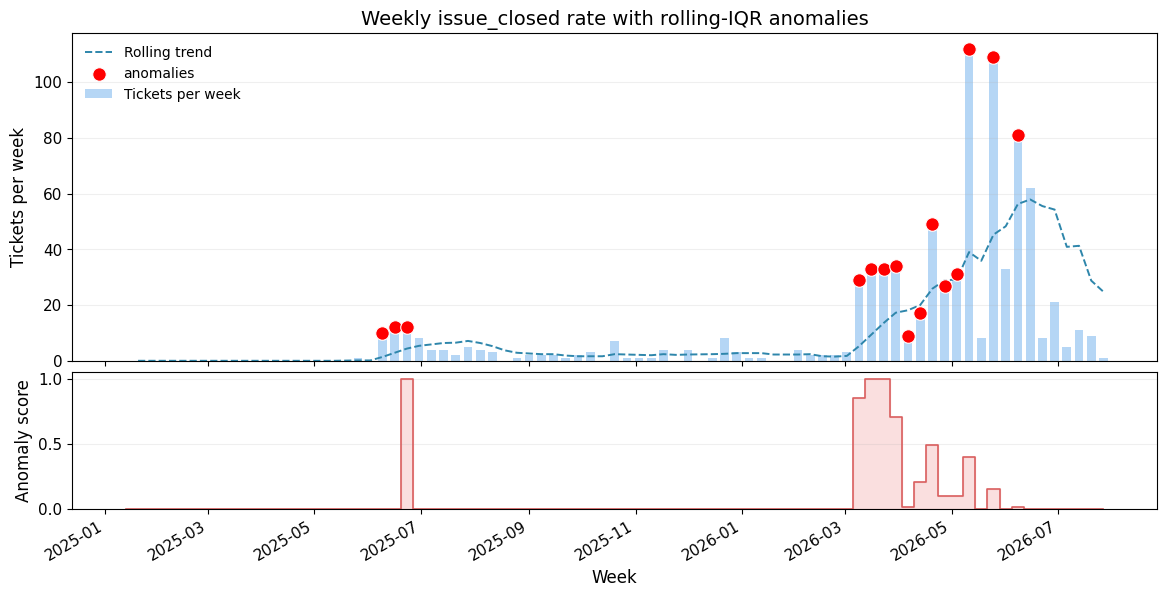

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/TradingAgents')

In [5]:
from functions.plotting_anomaly import plot_anomaly_figures

plot_anomaly_figures(rolling_iqr_anomalies, cfg)


## 5. Commit context and type classification

Link commits to issues that closed in anomaly weeks via the same `event_id` join as 8b. Classify those messages for the weekly stacked plot, and save overlapping `anomaly_issue_commit_categories`.


commit_context summary: 15 rows x 17 columns
Saved commit_context to C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\commit_context.csv

=== Anomaly issue commit categories (overlapping, event_id link) ===
Anomaly issues: 588
Issues with classified commits: 383
Issues with no classified commit (assigned to other): 205
Issues in more than one category: 145
  feature_work  151
  bug_fixes     153
  tech_debt     85
  docs          47
  other         423
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\anomaly_issue_commit_categories.csv
commit_typeclass_per_week summary: 15 rows x 33 columns

Mean category ratios across all anomaly weeks:
  feature_work  0.165
  bug_fixes     0.150
  tech_debt     0.108
  docs          0.045
  other         0.533

Mean category ratios by anomaly_direction

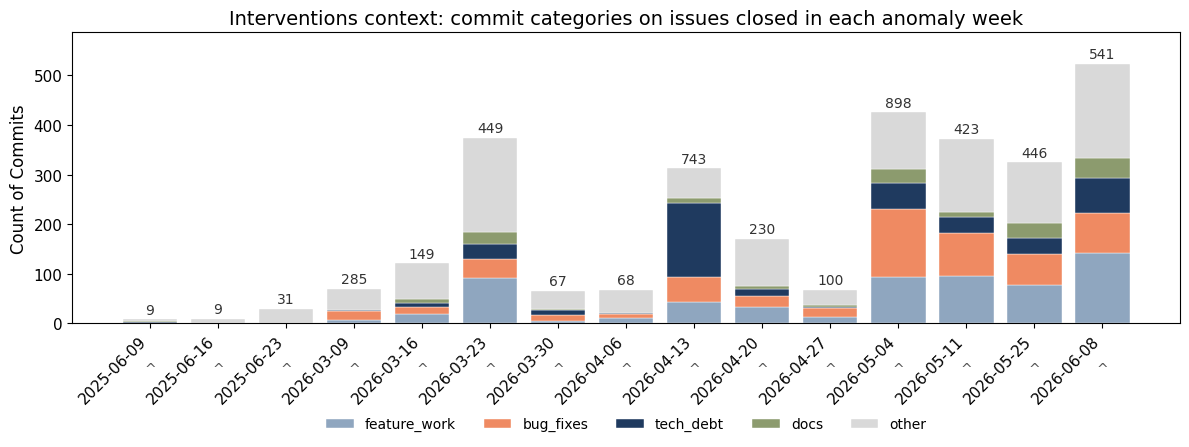

WindowsPath('C:/Users/mahsa.choopannezhadm/OneDrive - University of Liechtenstein/Desktop/PhD materials/codes/Lifecycles-Processes/results/figures/TradingAgents')

In [6]:
from functions.commits import build_commit_context, build_commit_typeclass
from functions.plotting_anomaly import plot_commit_category_stack

commit_context, event_commit_message_join, anomaly_issue_commit_categories = build_commit_context(
    rolling_iqr_anomalies, eventsPerobj_df, objects_attributes, cfg, anomaly_object_ids
)
commit_typeclass_per_week = build_commit_typeclass(commit_context, cfg)
plot_commit_category_stack(commit_context, commit_typeclass_per_week, cfg)


## 6. Flatten OCEL2 issue log: viewpoint of issues


In [7]:
from functions.ocel_flatten import flatten_ocel2_issue_log

flat = flatten_ocel2_issue_log(cfg)


Flattened log: 14059 events, 828 cases
  case:concept:name  concept:name            time:timestamp
0             11684       created 2026-06-28 21:14:25+00:00
1             11684  unsubscribed 2026-06-29 18:54:45+00:00
2             11684     commented 2026-07-04 15:58:06+00:00
3             11684     commented 2026-07-04 15:58:28+00:00
4             11684        closed 2026-07-05 14:38:38+00:00
5             11684     commented 2026-07-08 01:22:31+00:00
6             11733     committed 2026-06-28 06:18:32+00:00
7             11733     committed 2026-06-28 06:29:47+00:00
8             11733     committed 2026-06-28 06:39:02+00:00
9             11733     committed 2026-06-28 07:21:20+00:00


## 7a. Category-log preprocess 

Clean the raw step-6 `flat` log for commit-category discovery: keep cases that contain `closed` or `head_ref_deleted` anywhere (full traces), then drop traces with any activity repeating more than `CATEGORY_MAX_REP` times. Independent of step 8 (`MAX_REP=5`).


In [8]:
from functions.preprocessing import preprocess_flat_log

CATEGORY_MAX_REP = 1000
flat_df_category_clean = preprocess_flat_log(flat, cfg, max_rep=CATEGORY_MAX_REP) 


=== Category-log preprocess (contain=closed/head_ref_deleted, max_rep=1000) ===
Raw: 828 cases | 14059 events
After contain-end filter: 827 cases | 14050 events
After max_rep=1000: 827 cases | 14050 events


In [9]:
from functions.discovery import select_miners

# Available: alpha_classic, inductive_IM, heuristics_dep_0.5/0.6/0.7,
# inductive_IMf_noise_0.2/0.3/0.4, split_miner_eps_*_eta_*
# None runs all miners.
DISCOVERY_MINERS = [
    "inductive_IMf_noise_0.2",
    "split_miner_eps_0.2_eta_0.5",
    "heuristics_dep_0.5",
]


## 7b. Commit-category event logs (8a cleaned flat) and discovery in each action category

Classify every commit message and put each case from `flat_df_category_clean` into exactly one category log: if all of its commits share a category it stays there; if they span several categories (or it has no classified commit) it goes to `other`. Logs are disjoint. Then run discovery F1 on those five logs plus that cleaned whole log. Discovery methods come from `DISCOVERY_MINERS` in the cell after 8a (`None` runs all).


In [10]:
from functions.commits import build_whole_commit_category_logs
from functions.discovery import evaluate_clean_logs, select_miners

category_logs, issue_commit_categories, commit_classified_all = build_whole_commit_category_logs(
    flat_df_category_clean, eventsPerobj_df, objects_attributes, cfg
)

commit_category_log_groups_df = {**category_logs, "whole": flat_df_category_clean}

consolidated_results_table_commit_categories, commit_category_log_groups_eventlog, _ = evaluate_clean_logs(
    commit_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_commit_categories.csv"
)
consolidated_results_table_commit_categories.head()


=== Commit message classification (preprocessed whole log) ===
Preprocessed whole-log cases: 827
Classified unique commits: 7562
  feature_work  1919
  bug_fixes     1344
  tech_debt     995
  docs          410
  other         2894
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\commit_classified_all.csv

=== Issue commit categories (disjoint, preprocessed whole log) ===
Whole-log cases: 827
Issues with classified commits: 549
Issues with no classified commit (assigned to other): 278
Issues with mixed commit categories (assigned to other): 209
Issues in issue_commit_categories: 827
  feature_work  55
  bug_fixes     83
  tech_debt     12
  docs          7
  other         670
Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\issue_commit_categories.csv

=== Preprocessed-log commit-c

c:\Users\mahsa.choopannezhadm\anaconda3\envs\LCP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
replaying log with TBR, completed traces :: 100%|██████████| 588/588 [00:02<00:00, 224.82it/s]

Expected records: 18 | Observed: 18

7) Consolidated results table in clean logs
        log_name             discovery_method  n_cases  avg_cycle_time_days  \
0      bug_fixes           heuristics_dep_0.5       83            23.906641   
1           docs           heuristics_dep_0.5        7            66.698990   
2   feature_work           heuristics_dep_0.5       55            39.143571   
3          other           heuristics_dep_0.5      670            80.647260   
4      tech_debt           heuristics_dep_0.5       12           111.319748   
5          whole           heuristics_dep_0.5      827            72.519397   
6      bug_fixes      inductive_IMf_noise_0.2       83            23.906641   
7           docs      inductive_IMf_noise_0.2        7            66.698990   
8   feature_work      inductive_IMf_noise_0.2       55            39.143571   
9          other      inductive_IMf_noise_0.2      670            80.647260   
10     tech_debt      inductive_IMf_noise_0.2     

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,bug_fixes,heuristics_dep_0.5,83,23.906641,10.710843,0.564716,0.863715,0.501887,0.634866,241.0,10.0,0.482234,ok,None
1,docs,heuristics_dep_0.5,7,66.698990,9.142857,0.342276,0.918588,0.726027,0.811035,107.0,4.0,0.643836,ok,None
2,feature_work,heuristics_dep_0.5,55,39.143571,8.109091,0.470906,0.792535,0.630573,0.702338,246.0,18.0,0.470588,ok,None
3,other,heuristics_dep_0.5,670,80.647260,18.759701,0.496683,0.902240,0.272816,0.418951,653.0,37.0,0.453888,ok,None
4,tech_debt,heuristics_dep_0.5,12,111.319748,6.833333,0.393080,0.880029,0.537736,0.667562,108.0,2.0,0.589744,ok,None


## 7c. Anomaly vs normal logs from cleaned flat, then discovery F1

Split `flat_df_category_clean` by anomaly object IDs from step 3: keep matching cases as the anomaly log and the rest as the normal log. Then run discovery F1 on anomaly, normal, and the cleaned whole log using `DISCOVERY_MINERS`.


In [11]:
from functions.ocel_flatten import split_flat_by_anomaly_object_ids
from functions.discovery import evaluate_clean_logs, select_miners

anomaly_log_df, normal_log_df = split_flat_by_anomaly_object_ids(
    flat_df_category_clean, anomaly_object_ids
)

anomaly_normal_log_groups_df = {
    "anomaly": anomaly_log_df,
    "normal": normal_log_df,
    "whole": flat_df_category_clean,
}

consolidated_results_table_anomaly_normal, _, _ = evaluate_clean_logs(
    anomaly_normal_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_normal.csv",
)
consolidated_results_table_anomaly_normal


Anomaly log: 588 cases | 9367 events
Normal log: 239 cases | 4683 events


replaying log with TBR, completed traces :: 100%|██████████| 588/588 [00:02<00:00, 219.51it/s]

Expected records: 9 | Observed: 9

7) Consolidated results table in clean logs
  log_name             discovery_method  n_cases  avg_cycle_time_days  \
0  anomaly           heuristics_dep_0.5      588            85.327250   
1   normal           heuristics_dep_0.5      239            41.008865   
2    whole           heuristics_dep_0.5      827            72.519397   
3  anomaly      inductive_IMf_noise_0.2      588            85.327250   
4   normal      inductive_IMf_noise_0.2      239            41.008865   
5    whole      inductive_IMf_noise_0.2      827            72.519397   
6  anomaly  split_miner_eps_0.2_eta_0.5      588            85.327250   
7   normal  split_miner_eps_0.2_eta_0.5      239            41.008865   
8    whole  split_miner_eps_0.2_eta_0.5      827            72.519397   

   avg_trace_length  generalization   fitness  precision   f_score   size  \
0         15.930272        0.512195  0.882645   0.398179  0.548789  615.0   
1         19.594142        0.502862 

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,anomaly,heuristics_dep_0.5,588,85.327250,15.930272,0.512195,0.882645,0.398179,0.548789,615.0,38.0,0.447619,ok,None
1,normal,heuristics_dep_0.5,239,41.008865,19.594142,0.502862,0.915336,0.221178,0.356269,381.0,15.0,0.465409,ok,None
2,whole,heuristics_dep_0.5,827,72.519397,16.989117,0.528268,0.886821,0.241043,0.379057,679.0,42.0,0.445783,ok,None
3,anomaly,inductive_IMf_noise_0.2,588,85.327250,15.930272,0.708861,0.941358,0.524986,0.674057,315.0,7.0,0.625571,ok,None
4,normal,inductive_IMf_noise_0.2,239,41.008865,19.594142,0.693419,0.980877,0.666273,0.793531,170.0,1.0,0.627119,ok,None
5,whole,inductive_IMf_noise_0.2,827,72.519397,16.989117,0.743253,0.958978,0.526029,0.679391,390.0,7.0,0.629630,ok,None
6,anomaly,split_miner_eps_0.2_eta_0.5,588,85.327250,15.930272,0.762077,0.805088,0.297087,0.434017,515.0,99.0,0.376033,ok,None
7,normal,split_miner_eps_0.2_eta_0.5,239,41.008865,19.594142,0.660663,0.977497,0.233397,0.376821,248.0,2.0,0.536842,ok,None
8,whole,split_miner_eps_0.2_eta_0.5,827,72.519397,16.989117,0.733759,0.865756,0.249609,0.387497,417.0,60.0,0.402116,ok,None


## 7d. Anomaly x commit-category logs, then discovery F1

Cross `anomaly_log_df` / `normal_log_df` from 8c with disjoint `category_logs` from 8b: each case belongs to exactly one category, then those logs are split into anomaly vs normal. Then run discovery F1 on the ten combined groups plus the cleaned whole log using `DISCOVERY_MINERS`.


In [12]:
from functions.discovery import evaluate_clean_logs, select_miners

anomaly_ids = set(anomaly_log_df["case:concept:name"].astype(str))
normal_ids = set(normal_log_df["case:concept:name"].astype(str))

anomaly_category_log_groups_df = {
    **{f"anomaly_{name}": df[df["case:concept:name"].astype(str).isin(anomaly_ids)].copy()
       for name, df in category_logs.items()},
    **{f"normal_{name}": df[df["case:concept:name"].astype(str).isin(normal_ids)].copy()
       for name, df in category_logs.items()},
    "whole": flat_df_category_clean,
}

consolidated_results_table_anomaly_categories, _, _ = evaluate_clean_logs(
    anomaly_category_log_groups_df,
    cfg,
    miners=select_miners(DISCOVERY_MINERS),
    out_filename="consolidated_results_table_anomaly_categories.csv",
)
consolidated_results_table_anomaly_categories


replaying log with TBR, completed traces :: 100%|██████████| 588/588 [00:02<00:00, 213.31it/s]


Expected records: 33 | Observed: 33

7) Consolidated results table in clean logs
                log_name             discovery_method  n_cases  \
0      anomaly_bug_fixes           heuristics_dep_0.5       55   
1           anomaly_docs           heuristics_dep_0.5        5   
2   anomaly_feature_work           heuristics_dep_0.5       38   
3          anomaly_other           heuristics_dep_0.5      483   
4      anomaly_tech_debt           heuristics_dep_0.5        7   
5       normal_bug_fixes           heuristics_dep_0.5       28   
6            normal_docs           heuristics_dep_0.5        2   
7    normal_feature_work           heuristics_dep_0.5       17   
8           normal_other           heuristics_dep_0.5      187   
9       normal_tech_debt           heuristics_dep_0.5        5   
10                 whole           heuristics_dep_0.5      827   
11     anomaly_bug_fixes      inductive_IMf_noise_0.2       55   
12          anomaly_docs      inductive_IMf_noise_0.2        

,log_name,discovery_method,n_cases,avg_cycle_time_days,avg_trace_length,generalization,fitness,precision,f_score,size,cfc,simplicity,status,error
0,anomaly_bug_fixes,heuristics_dep_0.5,55,27.706577,11.600000,0.524746,0.838856,0.649289,0.731999,226.0,12.0,0.468085,ok,None
1,anomaly_docs,heuristics_dep_0.5,5,92.050150,10.400000,0.292988,0.909127,0.755102,0.824987,97.0,3.0,0.661538,ok,None
2,anomaly_feature_work,heuristics_dep_0.5,38,48.054550,8.763158,0.462797,0.797210,0.611621,0.692191,254.0,16.0,0.480769,ok,None
3,anomaly_other,heuristics_dep_0.5,483,93.410103,17.175983,0.491923,0.894398,0.316958,0.468048,568.0,30.0,0.452282,ok,None
4,anomaly_tech_debt,heuristics_dep_0.5,7,177.879636,6.857143,0.307308,0.976190,0.879310,0.925221,89.0,0.0,0.639344,ok,None
5,normal_bug_fixes,heuristics_dep_0.5,28,16.442480,8.964286,0.454172,0.875597,0.516224,0.649515,188.0,6.0,0.549296,ok,None
6,normal_docs,heuristics_dep_0.5,2,3.321088,6.000000,0.183058,1.000000,1.000000,1.000000,32.0,0.0,1.000000,ok,None
7,normal_feature_work,heuristics_dep_0.5,17,19.224910,6.647059,0.375082,0.872050,0.672269,0.759237,130.0,3.0,0.551020,ok,None
8,normal_other,heuristics_dep_0.5,187,47.682268,22.850267,0.456867,0.931341,0.211202,0.344321,371.0,13.0,0.472313,ok,None
9,normal_tech_debt,heuristics_dep_0.5,5,18.135905,6.800000,0.363302,0.938842,0.561644,0.702832,57.0,1.0,0.722222,ok,None


In [14]:
import pandas as pd

xlsx_path = cfg.tables_dir / "consolidated_results_tables.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    consolidated_results_table_commit_categories.to_excel(
        writer, sheet_name="commit_categories", index=False
    )
    consolidated_results_table_anomaly_normal.to_excel(
        writer, sheet_name="anomaly_normal", index=False
    )
    consolidated_results_table_anomaly_categories.to_excel(
        writer, sheet_name="anomaly_categories", index=False
    )
print(f"Saved {xlsx_path}")


Saved C:\Users\mahsa.choopannezhadm\OneDrive - University of Liechtenstein\Desktop\PhD materials\codes\Lifecycles-Processes\results\tables\TradingAgents\consolidated_results_tables.xlsx


## 8. Petri nets by commit category: events related to each commit category


the question:

what process is discovered for each disjoint commit category in the preprocessed whole log?

the input:

category_logs from step 8b (disjoint category subsets of flat_df_category_clean)

the output:

petri net per category log (inductive_IMf_noise_0.2)


In [15]:
#graphviz path 
import os
from pathlib import Path
import shutil

GRAPHVIZ_BIN = Path(r"C:\Program Files\Graphviz\bin")  # change if yours is elsewhere

if not (GRAPHVIZ_BIN / "dot.exe").exists():
    raise FileNotFoundError(
        f"dot.exe not found in {GRAPHVIZ_BIN}. "
        "Install Graphviz and set GRAPHVIZ_BIN to its bin folder."
    )

os.environ["PATH"] = str(GRAPHVIZ_BIN) + os.pathsep + os.environ.get("PATH", "")
print("dot found at:", shutil.which("dot"))

dot found at: C:\Program Files\Graphviz\bin\dot.EXE


feature_work


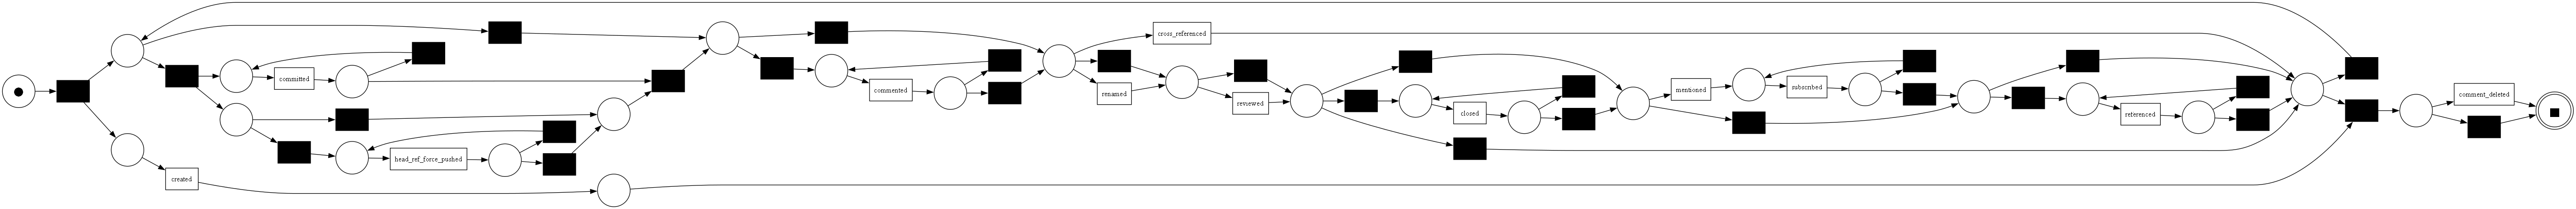

bug_fixes


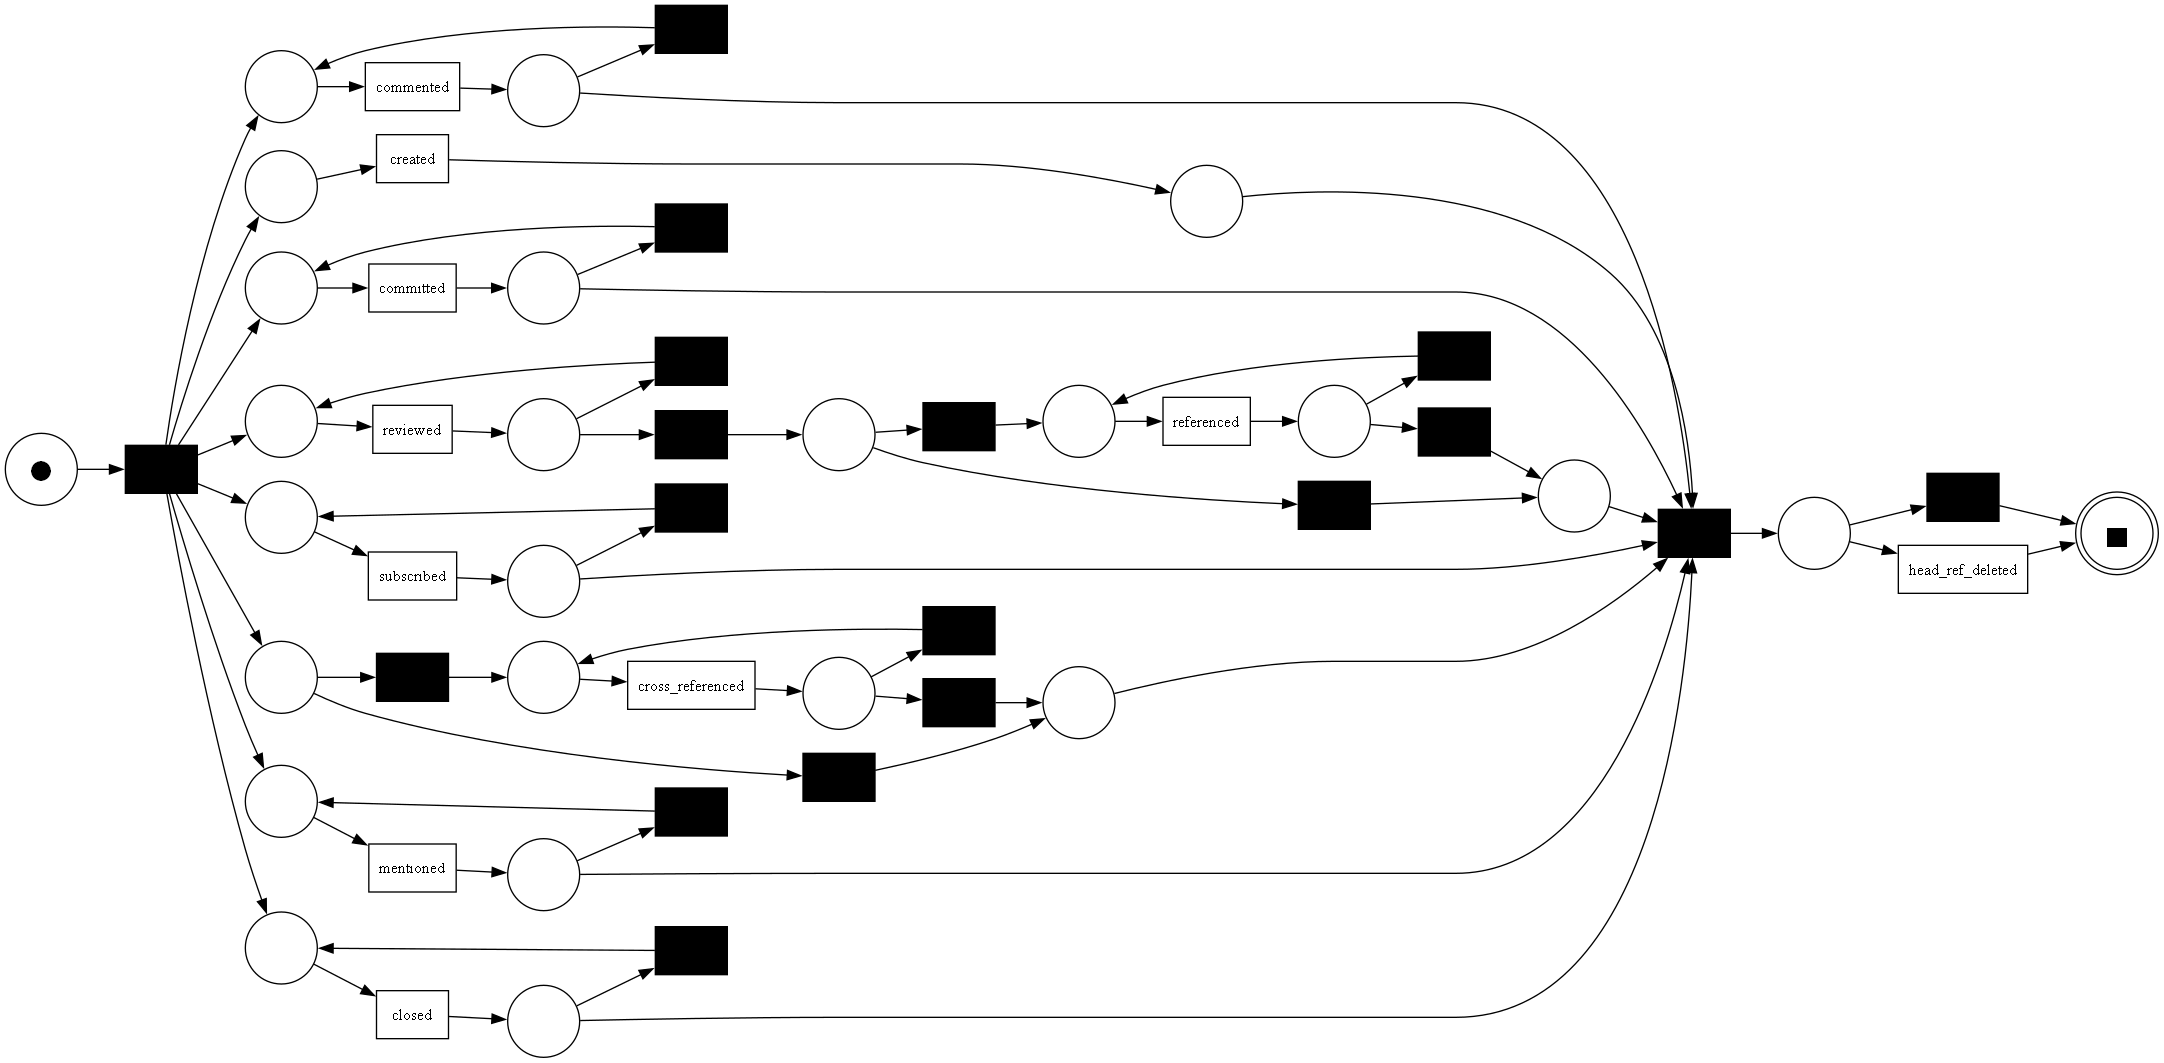

tech_debt


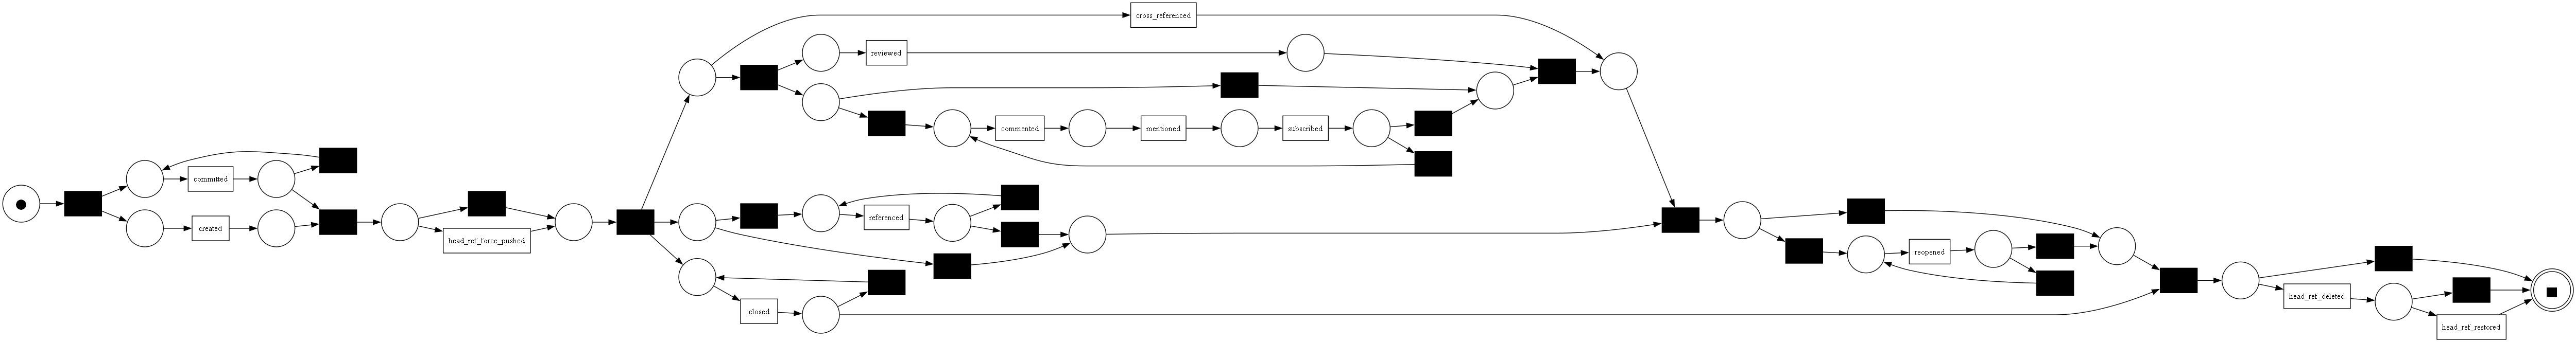

docs


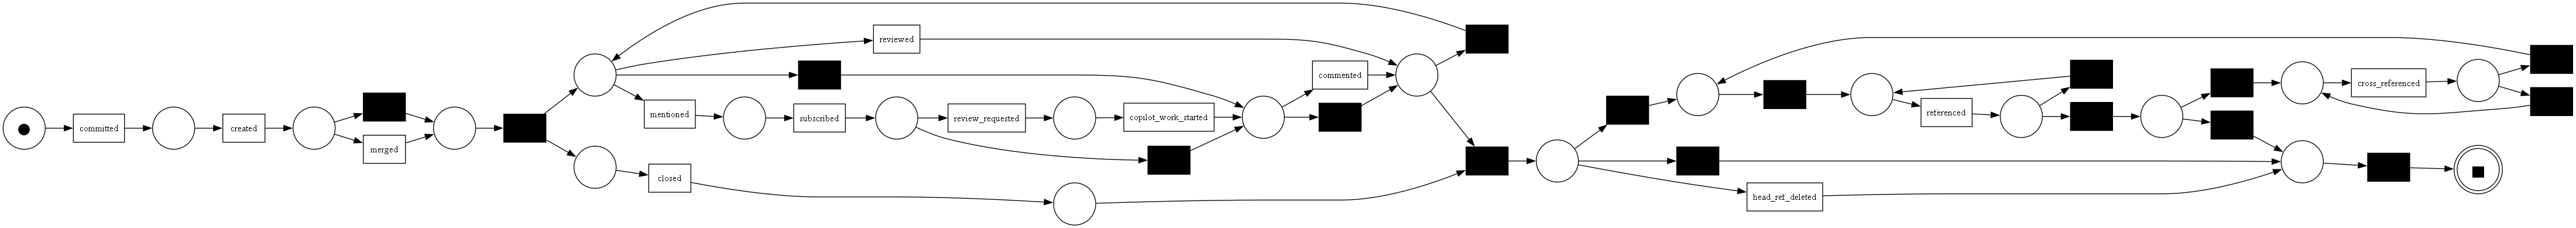

other


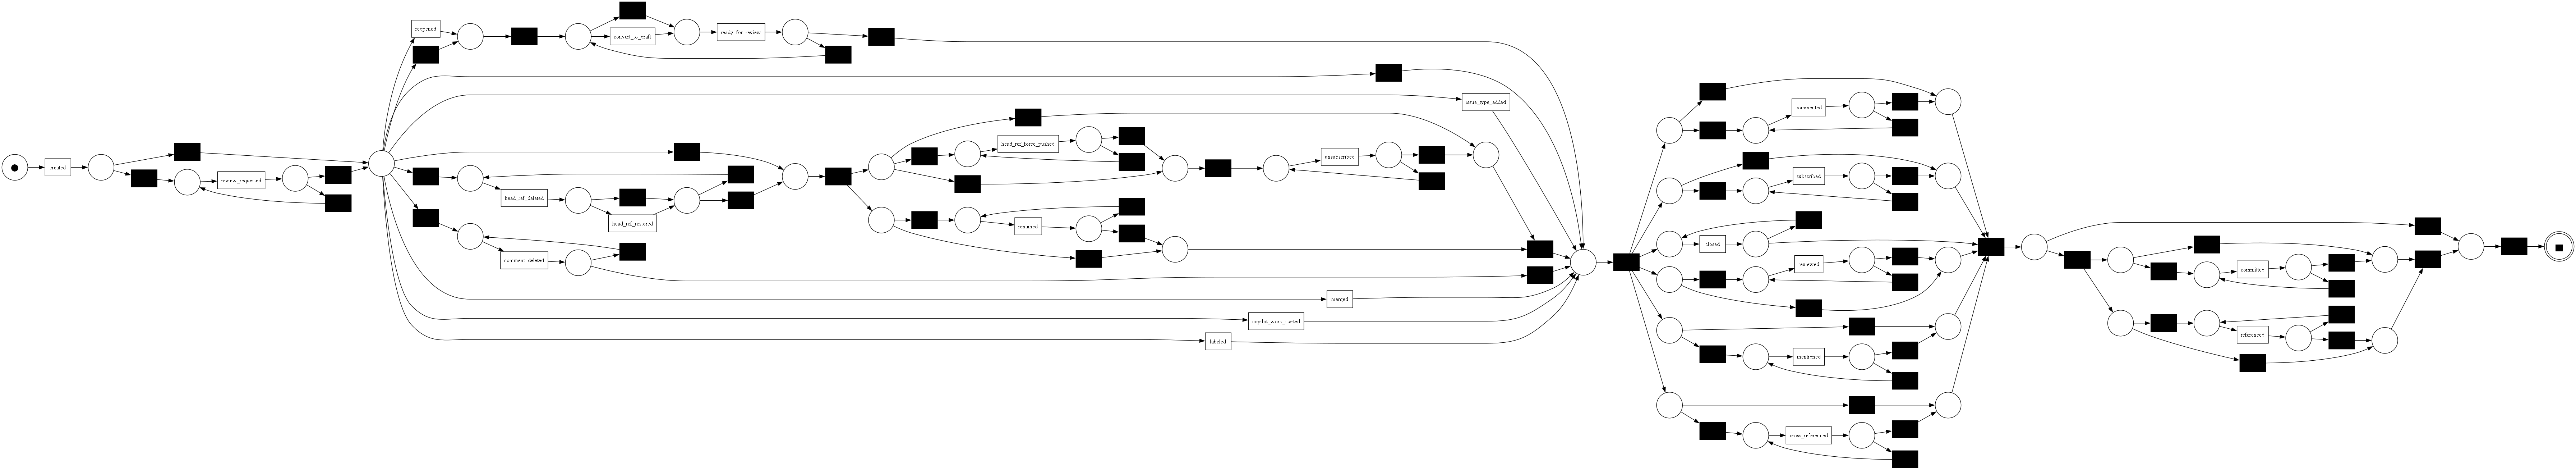

In [16]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.2"])

for name, df in category_logs.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.2"](elog)
    pm4py.view_petri_net(net, im, fm)


## 9. Petri nets by anomaly, normal, and whole

the question:

    what process is discovered for anomaly vs normal vs the whole cleaned log?

the input:

    anomaly_normal_log_groups_df from step 8c

the output:

    petri net per log (inductive_IMf_noise_0.2)

anomaly


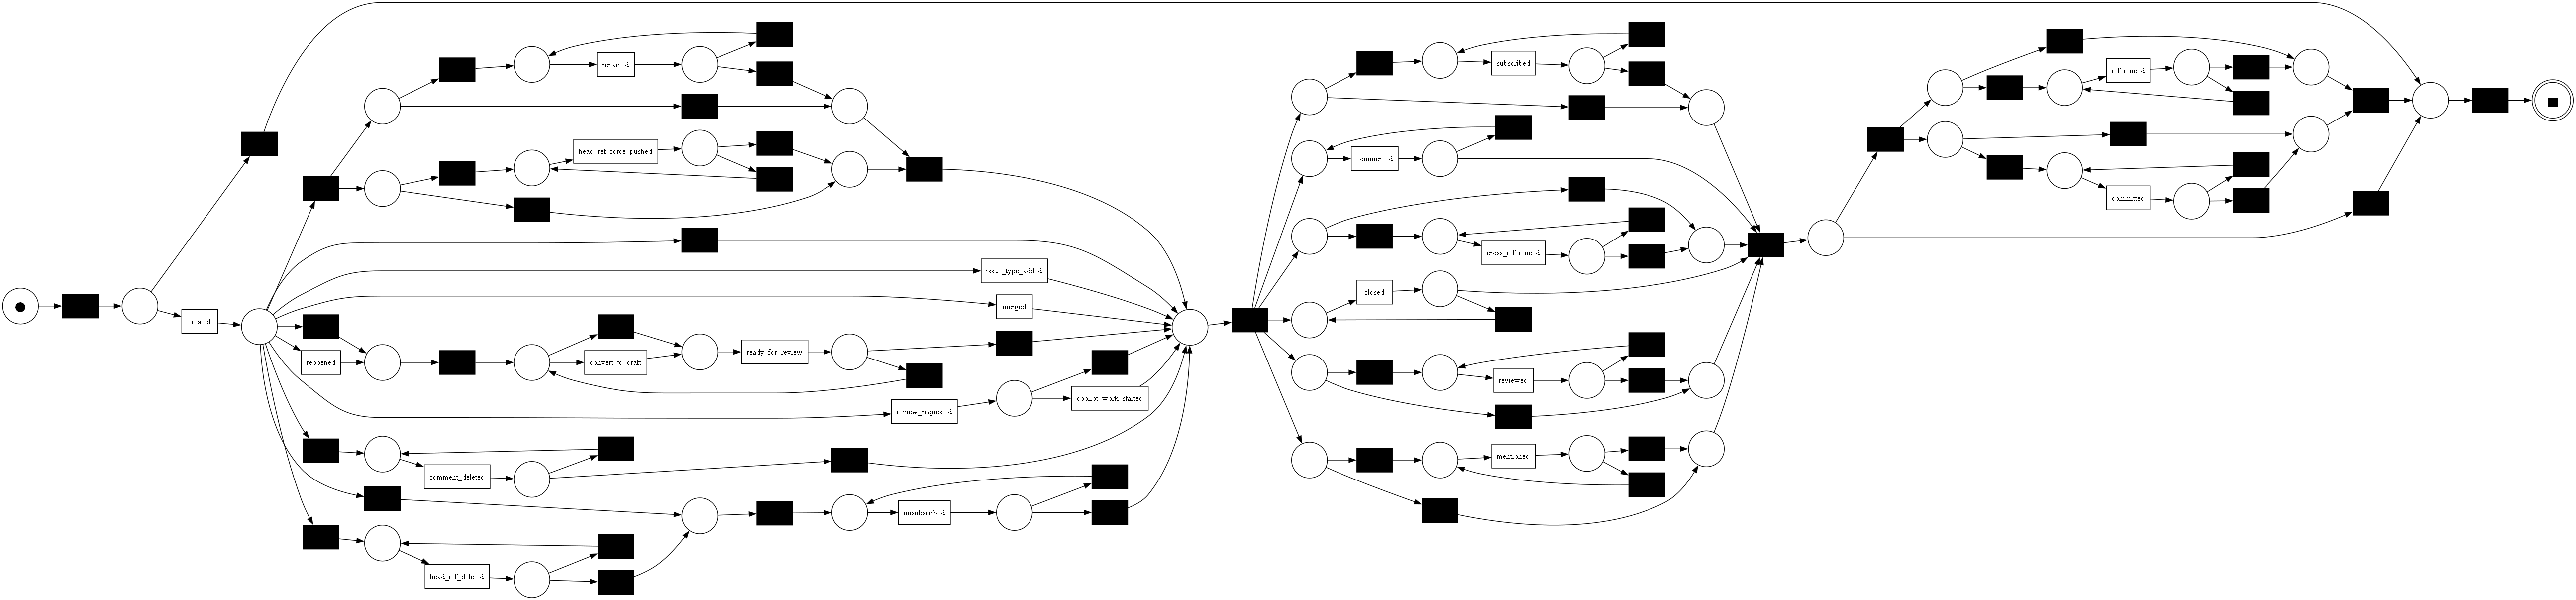

normal


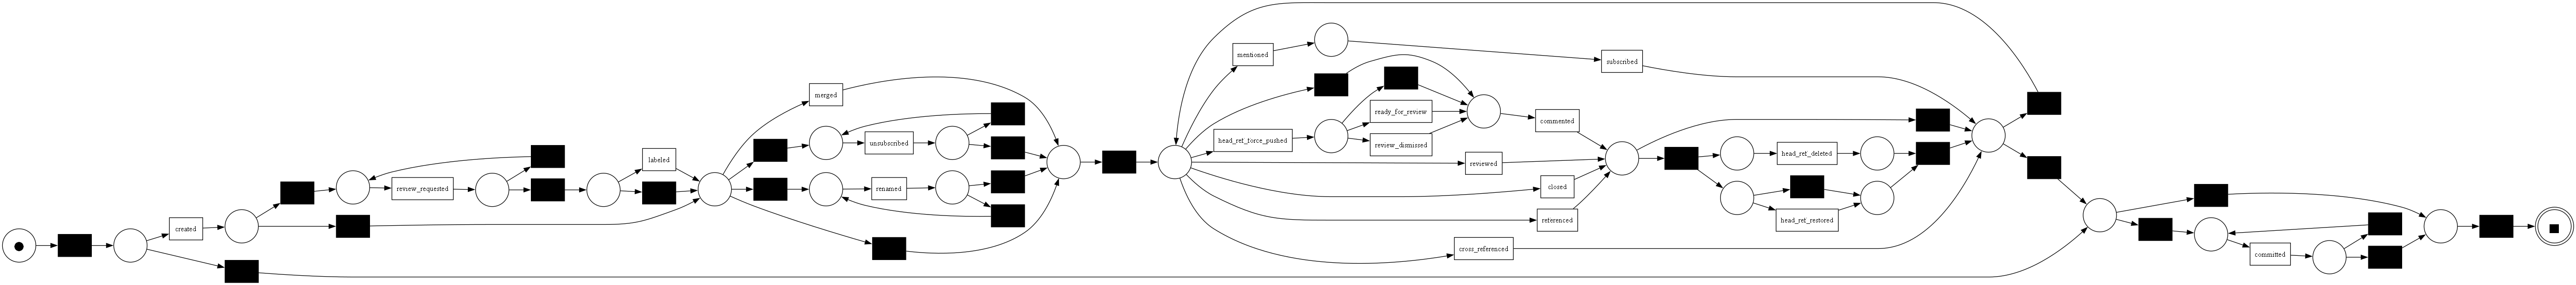

whole


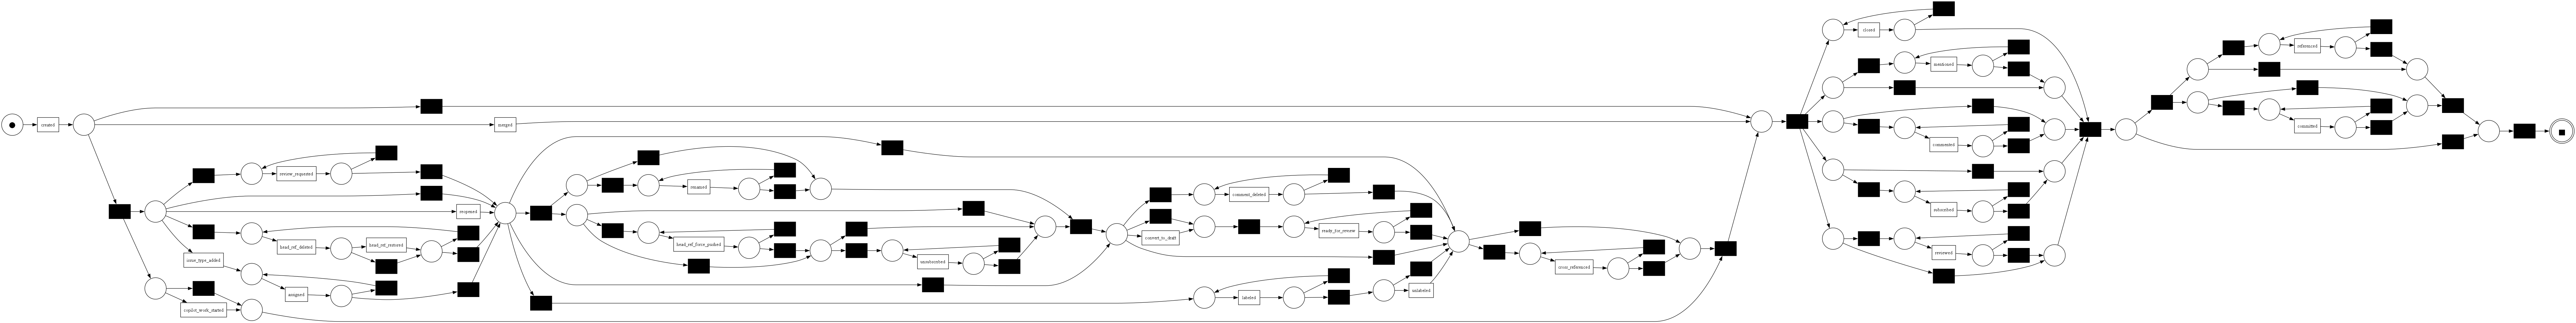

In [17]:
import pm4py
from functions.discovery import df_to_event_log, select_miners

miners = select_miners(["inductive_IMf_noise_0.2"])

for name, df in anomaly_normal_log_groups_df.items():
    print(name)
    elog = df_to_event_log(df)
    net, im, fm = miners["inductive_IMf_noise_0.2"](elog)
    pm4py.view_petri_net(net, im, fm)
